In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Epsilon  = 1.0
V = 0.8

This is the general equation for the LMG MOdel for second quatisation to model a system where there is two fermions that are no identical within area :

$$
H=\frac{1}{2}\varepsilon\sum_{p\sigma}\sigma\hat{a}^\dagger_{p\sigma}a_{p\sigma}+\frac{1}{2}V\sum_{pp'\sigma}\hat{a}^\dagger_{p\sigma}\hat{a}^\dagger_{p'\sigma}a_{p'-\sigma}a_{p-\sigma}
$$

Where the first term represents the The single body of eachfermion and the second term represnts the interaction term.

the first term has two components :
$$
\frac{1}{2}\varepsilon\sum_{p\sigma}\sigma\hat{a}^\dagger_{p\sigma}a_{p\sigma}=\frac{1}{2}\varepsilon\sum_{p}\hat{a}^\dagger_{p+}a_{p+}-\frac{1}{2}\varepsilon\sum_{p}\hat{a}^\dagger_{p-}a_{p-}.
$$

The Jw models converts the The hamiltonian from just operators into gate so it can be ccomputed.

$$
H=\frac{1}{4}\varepsilon\left(Z_1+Z_2-Z_3-Z_4\right) + \frac{1}{8}V(X_1 X_2 X_3 X_4-X_1 X_2 Y_3 Y_4+X_1 Y_2 Y_3X_4+X_1 Y_2 X_3Y_4+Y_1 X_2Y_3X_4+Y_1X_2X_3Y_4-Y_1 Y_2 X_3 X_4+Y_1 Y_2 Y_3 Y_4)
$$

The trotter formula essentially allows us to make accurate approximation of hamiltonians which are broken down into smaller matricies that do not commute for example:

H = A+B where AB-BA $\not=$ 0

In [3]:
ob1 = qml.Z(0) @ qml.I(1) @ qml.I(2) @ qml.I(3)
ob2 = qml.I(0) @ qml.Z(1) @ qml.I(2) @ qml.I(3)
ob3 = qml.I(0) @ qml.I(1) @ qml.Z(2) @ qml.I(3)
ob4 = qml.I(0) @ qml.I(1) @ qml.I(2) @ qml.Z(3)

h_1 = 0.25*Epsilon*(ob1+ob2+-ob3-ob4) # expression for single body term 

tb1 = qml.X(0) @ qml.X(1) @ qml.X(2) @ qml.X(3)
tb2 = qml.X(0) @ qml.X(1) @ qml.Y(2) @ qml.Y(3)
tb3 = qml.X(0) @ qml.Y(1) @ qml.Y(2) @ qml.X(3)
tb4 = qml.X(0) @ qml.Y(1) @ qml.X(2) @ qml.Y(3)
tb5 = qml.Y(0) @ qml.X(1) @ qml.Y(2) @ qml.X(3)
tb6 = qml.Y(0) @ qml.X(1) @ qml.X(2) @ qml.Y(3)
tb7 = qml.Y(0) @ qml.Y(1) @ qml.X(2) @ qml.X(3)
tb8 = qml.Y(0) @ qml.Y(1) @ qml.Y(2) @ qml.Y(3)

h_v =  V*(tb1-tb2+tb3+tb4+tb5+tb6-tb7+ tb8)*0.125 #expression for the interaction term 

hamiltonian = h_1 + h_v #Full hamiltonian for single and interaction term

In [4]:
np.set_printoptions(linewidth=np.inf, suppress=True) # i want to here suppress very small values such e-16 as 0 so i can workwith 
#important coefficients

In [5]:
H_as_matrix = qml.matrix(hamiltonian) # convert hamiltonian into a matrix 
eval, evec = np.linalg.eigh(H_as_matrix) # work out eigen values and vectors
print("eigenvalues: ",eval, "\neigenvectors: \n ",evec) # print out eigen values and vectors

eigenvalues:  [-1.28062485 -0.5        -0.5        -0.5        -0.5         0.          0.          0.          0.          0.          0.          0.5         0.5         0.5         0.5         1.28062485] 
eigenvectors: 
  [[ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  1.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j -0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  1.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j -0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j  1.        +0.j  0.        +0.j -0.        +0.

In [6]:
C = np.zeros(16, dtype=complex)
for i in range (0,16):
    C[i] = np.dot([0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],evec[:,i]) #obtain cofficients for specifc states to use in p1 
    # and put |0011> in the same basis as H 

In [7]:
C

array([-0.33100694+0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j, -0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j, -0.94362832+0.j])

In [8]:
eval = eval.real # got rid of the complex numbers
eval = eval.tolist() # instead of array list i want normal list 
eigen_values= []
#want to just isolate the eigen values i want
for i in eval:
    ii = i*i
    eigen_values.append(ii**0.5) # i create a list of absoloute numbers

In [9]:
eigen_values = sorted(eigen_values, reverse=True) # i want the eigen values i want to work with in 0 and 1.
eigen_values

[1.2806248474865698,
 1.2806248474865696,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.49999999999999994,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [10]:
E0 = -eigen_values[1]
E1 = eigen_values[0]
delta_E = E1 - (E0) #finding the energy gap between two levels
n = 50 #steps
dt = (2*np.pi)/(delta_E*n) #defining dt for time increment
t = np.linspace(0,2.0*np.pi/delta_E,n,endpoint=True) # setting up the time intreval

The p1 formual is the probabiltiy expression for obtaining 0011 state. by making t evlove over steps from 0 to 2pi we get to see how the analytical or precise evoloution of how the probablities of state 0011 evloves over time. 

In [11]:
p1_0011 = C[0]**4 + C[-1]**4 + (2*(C[0]**2)*(C[-1]**2)*(np.cos(delta_E*t))) # expression for p1

theta_1 = 0.5 * Epsilon * dt #expression for theta 1 in single body terms 
theta_2 = 0.25 * V * dt #interaction terms

In [12]:
dev = qml.device("default.qubit", wires=4)

In [13]:
@qml.qnode(dev) # circuit i use to use to initialise the ciruit into |0011>
def initialize():
    qml.X(2)
    qml.X(3)
    return qml.state()

Manually setting up the trotter circuit 

In [14]:
@qml.qnode(dev)
def circuit(state,theta_1, theta_2):

    qml.StatePrep(state, wires=[0,1,2,3])


    # Single Body term 
    qml.RZ(theta_1,0)
    qml.RZ(theta_1,1)
    qml.RZ(-theta_1,2)
    qml.RZ(-theta_1,3)

    #interaction terms
    # tb1
    qml.PauliRot(theta_2, "XXXX", wires=[0, 1, 2, 3])
    # tb2
    qml.PauliRot(-theta_2, "XXYY", wires=[0, 1, 2, 3])
    # tb3
    qml.PauliRot(theta_2, "XYYX", wires=[0, 1, 2, 3])
    # tb4
    qml.PauliRot(theta_2, "XYXY", wires=[0, 1, 2, 3])
    # tb5
    qml.PauliRot(theta_2, "YXYX", wires=[0, 1, 2, 3])
    # tb6
    qml.PauliRot(theta_2, "YXXY", wires=[0, 1, 2, 3])
    # tb7
    qml.PauliRot(-theta_2, "YYXX", wires=[0, 1, 2, 3])
    # tb8
    qml.PauliRot(theta_2, "YYYY", wires=[0, 1, 2, 3])
    

    return qml.state()

In [15]:
state=initialize()
manual_circuit_output = circuit(state,theta_1, theta_2)

In [16]:
def probabilties_with_bitstring_labels(empty_list,list_of_states): #fucntion i use to print my states with probabiltities 
    bit_strings = [f"{x:0{4}b}" for x in range(len(list_of_states))]
    for i in range(0,len(list_of_states)):
        dict_1 = {'state': '','probability':''}
        dict_1['state'] = bit_strings[i]
        dict_1['probability'] = list_of_states[i]
        empty_list.append(dict_1)
    return empty_list

In [17]:
def real_number_converter(list_states_probabilities): #fucntion i use to turn my probabilities into actual numbers
    for items in list_states_probabilities:
        items['probability'] = abs(items['probability'])**2
    return list_states_probabilities

In [18]:
# code for the manual circuit implementation
state_and_probabilties_manual_circuit = []
state_and_probabilties_manual_circuit = probabilties_with_bitstring_labels(state_and_probabilties_manual_circuit, manual_circuit_output)
state_and_probabilties_manual_circuit = real_number_converter(state_and_probabilties_manual_circuit)
state_and_probabilties_manual_circuit

[{'state': '0000', 'probability': np.float64(1.5758815609726165e-36)},
 {'state': '0001', 'probability': np.float64(0.0)},
 {'state': '0010', 'probability': np.float64(0.0)},
 {'state': '0011', 'probability': np.float64(0.9984601698338919)},
 {'state': '0100', 'probability': np.float64(1.805619552464323e-35)},
 {'state': '0101', 'probability': np.float64(0.0)},
 {'state': '0110', 'probability': np.float64(0.0)},
 {'state': '0111', 'probability': np.float64(3.849542391744912e-33)},
 {'state': '1000', 'probability': np.float64(2.0207937074471615e-36)},
 {'state': '1001', 'probability': np.float64(0.0)},
 {'state': '1010', 'probability': np.float64(0.0)},
 {'state': '1011', 'probability': np.float64(2.617543740407426e-32)},
 {'state': '1100', 'probability': np.float64(0.001539830166104232)},
 {'state': '1101', 'probability': np.float64(0.0)},
 {'state': '1110', 'probability': np.float64(0.0)},
 {'state': '1111', 'probability': np.float64(3.850284007213483e-33)}]

c:\Users\Ahmed\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Ahmed\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


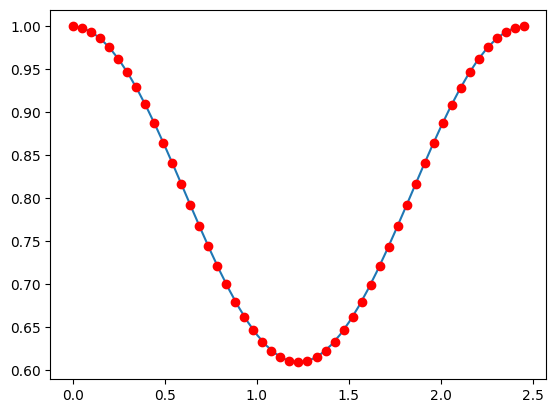

In [19]:
# code for the graph from manual operation
state=initialize()
plt.plot(t,p1_0011)
plt.plot(0,1,'ro')

for i in range(0,n):
    step_state = circuit(state,theta_1, theta_2)
    p1o = abs(step_state[3])**2
    plt.plot((i+1)*dt,p1o,'ro')
    state=step_state

plt.show()

Here i Set up the trotter circuit by using the pennylane speciliased fucntion which is easier and more automated.

In [20]:
@qml.qnode(dev)

def trotter(state):
    
    qml.StatePrep(state, wires=range(4)) 

    
    qml.TrotterProduct(hamiltonian, time=dt, order=1)

    return qml.state()

In [21]:
list_of_states_trotter = trotter(state)
state_and_probabilities_trotter = []
state_and_probabilities_trotter = probabilties_with_bitstring_labels(state_and_probabilities_trotter, list_of_states_trotter)
state_and_probabilities_trotter = real_number_converter(state_and_probabilities_trotter)
state_and_probabilities_trotter

[{'state': '0000', 'probability': np.float64(1.4940140748429245e-30)},
 {'state': '0001', 'probability': np.float64(0.0)},
 {'state': '0010', 'probability': np.float64(0.0)},
 {'state': '0011', 'probability': np.float64(0.9984359870387144)},
 {'state': '0100', 'probability': np.float64(9.424146401838948e-30)},
 {'state': '0101', 'probability': np.float64(0.0)},
 {'state': '0110', 'probability': np.float64(0.0)},
 {'state': '0111', 'probability': np.float64(5.0062047912531704e-30)},
 {'state': '1000', 'probability': np.float64(1.4122393164054244e-30)},
 {'state': '1001', 'probability': np.float64(0.0)},
 {'state': '1010', 'probability': np.float64(0.0)},
 {'state': '1011', 'probability': np.float64(3.4571867274593103e-29)},
 {'state': '1100', 'probability': np.float64(0.0015640129610824994)},
 {'state': '1101', 'probability': np.float64(0.0)},
 {'state': '1110', 'probability': np.float64(0.0)},
 {'state': '1111', 'probability': np.float64(2.411242716913849e-30)}]

Here i just verify if my manual circuit and my trotter match

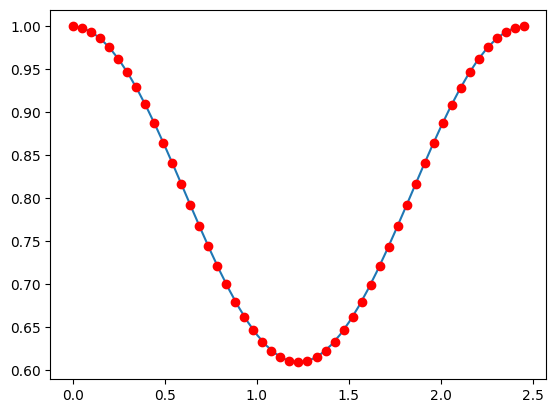

In [22]:
# code for graph from trotter automated circuit penny lane
state=initialize()
plt.plot(t,p1_0011)
plt.plot(0,1,'ro')

for i in range(0,n):
    step_state = trotter(state)
    p1o = abs(step_state[3])**2
    plt.plot((i+1)*dt,p1o,'ro')
    state=step_state

plt.show()

The blue curve represents the exact analytical solution, while the red dots show the Trotter approximation at each time step — the closer the dots follow the curve, the better the approximation.